In [81]:
import numpy as np
import torch
import pandas as pd
import matplotlib.pyplot as plt
import torch.nn as nn
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

In [89]:
"""Detail of CSV file:"""
#h=house for short form
h = pd.read_csv('housing.csv')
# Dataset structure and health checks
print("Shape:", h.shape) #(row,col)
print("Columns:", h.columns.tolist()) #list of all column
print("Missing values per column:\n", h.isnull().sum())
"""
dropna():
method returns a new DataFrame, and will not change the original.
If you want to change the original DataFrame, use the inplace = True argument:
 Now, the dropna(inplace = True) will NOT return a new DataFrame, but it will remove all rows containing NULL values from the original DataFrame.
 The fillna():
  method allows us to replace empty cells with a value. with uses the mean() median() and mode() methods to calculate the respective values

#Shows statistical summaries of the data.
print(h.describe())

#to count the number of non-missing (non-null) values in  dataset.
print(h.count())

#Shows the structural health of the DataFrame.
print(h.info())

#for fist
h.head()
#for last
h.tail()

#Count list of NULL in column
print(h.isnull().sum())
#Return True / False for any NULL value
print(h.isnull().values.any())
"""

Shape: (5000, 7)
Columns: ['Avg. Area Income', 'Avg. Area House Age', 'Avg. Area Number of Rooms', 'Avg. Area Number of Bedrooms', 'Area Population', 'Price', 'Address']
Missing values per column:
 Avg. Area Income                0
Avg. Area House Age             0
Avg. Area Number of Rooms       0
Avg. Area Number of Bedrooms    0
Area Population                 0
Price                           0
Address                         0
dtype: int64


'\ndropna() method returns a new DataFrame, and will not change the original.\nIf you want to change the original DataFrame, use the inplace = True argument:\n Now, the dropna(inplace = True) will NOT return a new DataFrame, but it will remove all rows containing NULL values from the original DataFrame.\n The fillna() method allows us to replace empty cells with a value. with uses the mean() median() and mode() methods to calculate the respective values\n\n#Shows statistical summaries of the data.\nprint(h.describe())\n\n#to count the number of non-missing (non-null) values in  dataset.\nprint(h.count())\n\n#Shows the structural health of the DataFrame.\nprint(h.info())\n\n#for fist\nh.head()\n#for last\nh.tail()\n\n#Count list of NULL in column\nprint(h.isnull().sum())\n#Return True / False for any NULL value\nprint(h.isnull().values.any())\n'

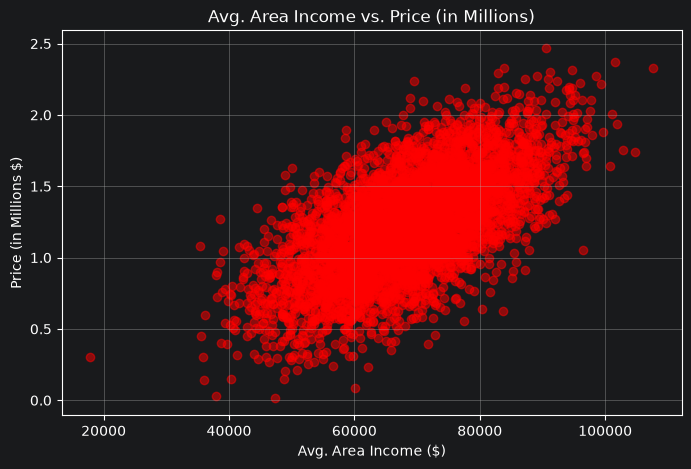

In [95]:
"""#Note-no need of data  cleaning as it already clean
h['Price_Millions'] = h['Price'] / 1000000
#h.plot.scatter(x="Avg. Area Income", y="Price_Millions", )
#h.plot(x="Avg. Area Income", y="Price_Millions", kind="scatter", xlabel="Avg Area Income", ylabel="Price (in Millions)")
print(h.plot("Avg. Area Income", "Price_Millions",ylabel="Price (in Millions)"))
print(h.plot.scatter("Price_Millions","Avg. Area Income",xlabel="Price (in Millions)"))"""
# Feature scaling for target column
h['Price_Millions'] = h['Price'] / 1000000

# Scatter Plot: Income vs House Price
plt.figure(figsize=(8, 5))
plt.scatter(h['Avg. Area Income'], h['Price_Millions'], alpha=0.5, c='red')
plt.title('Avg. Area Income vs. Price (in Millions)')
plt.xlabel('Avg. Area Income ($)')
plt.ylabel('Price (in Millions $)')
plt.grid(True)
plt.show()

In [99]:
"""Creating Test Set:(Note it good method for creating test set from training set """
data = h#housing file
def split_train_test(data, test_ratio):
    shuffled_indices = np.random.permutation(len(data))
    test_set_size = int(len(data) * test_ratio)
    test_indices = shuffled_indices[:test_set_size]
    train_indices = shuffled_indices[test_set_size:]
    return data.iloc[train_indices], data.iloc[test_indices]
#
train_set, test_set = split_train_test(h, 0.2)
print(len(train_set), "train +", len(test_set), "test")

4000 train + 1000 test


In [85]:
# Selects 80% of rows, BUT ONLY the "Avg. Area Income" column
x_train = train_set[["Avg. Area Income"]]

# Selects the matching 80% of rows, BUT ONLY the "Price_Millions" column
y_train = train_set["Price_Millions"]

# Selects the remaining 20% of rows, BUT ONLY the "Avg. Area Income" column
x_test = test_set[["Avg. Area Income"]]

# Selects the matching remaining 20% of rows, BUT ONLY the "Price_Millions" column
y_test = test_set["Price_Millions"]
"""
LinearRegression(): Initializes a Scikit-Learn linear regression model object.regr.fit(...):
 Trains the model by finding the optimal straight line ($y = mx + c$)
 that fits your training data (x_train and y_train).np.array(...).reshape(-1, 1):
 Converts x_train into a 2D array with 1 column and as many rows as needed (-1).
  Scikit-Learn requires feature matrices ($X$) to be 2D.
  (Note: If you used X_train = train_set[["Avg. Area Income"]] with double brackets,
   it is already 2D, so .reshape() isn't strictly necessary)."""
regr = LinearRegression()
regr.fit(np.array(x_train).reshape(-1,1), y_train)
preds = regr.predict(np.array(x_test).reshape(-1,1))
#y_test.head()
#print(preds)
residuals = preds - y_test

#plt.hist(residuals)


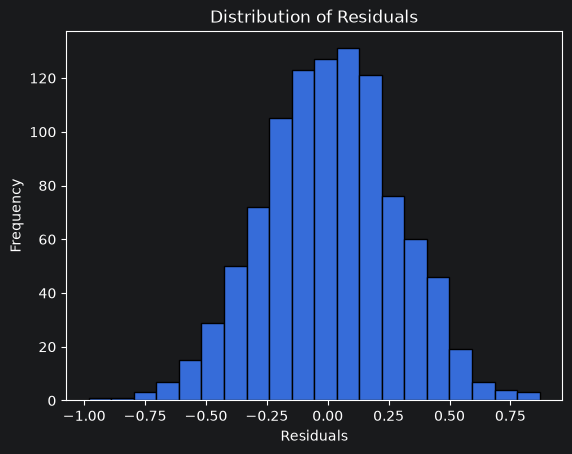

In [87]:
plt.hist(residuals, bins=20, edgecolor="black")
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.title("Distribution of Residuals")
plt.show()

In [125]:
loss=mean_squared_error(y_test, preds) ** 0.5
print(loss)

1290631.9196412915


In [122]:
import numpy as np
#
# 1. Ask the user for input
user_income = int( input("Enter the Average Area Income : "))

# 2. Format input as a 2D array [[value]]
# Scikit-learn models ALWAYS expect a 2D matrix for X input
user_input_array = np.array([[user_income]])

# 3. Predict using the trained model
predicted_price = regr.predict(user_input_array)

# 4. Display the result
# predicted_price[0] extracts the single scalar value from the returned array
print(f"\nPredicted House Price: ${predicted_price[0]*100000:,.2f} ")


Predicted House Price: $50,319.09 


In [123]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
# Define Features (X) and Target (y)
features = ['Avg. Area Income', 'Avg. Area House Age', 'Avg. Area Number of Rooms',
            'Avg. Area Number of Bedrooms', 'Area Population']
X = h[features]
y = h['Price']

# Split Data (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Model Training
model = LinearRegression()
model.fit(X_train, y_train)

# Evaluation
y_pred = model.predict(X_test)
rmse = mean_squared_error(y_test, y_pred) #squared=False)
r2 = r2_score(y_test, y_pred)

print(f"Root Mean Squared Error (RMSE): ${rmse:,.2f}")
print(f"R² Score: {r2:.4f}")

Root Mean Squared Error (RMSE): $10,089,009,299.50
R² Score: 0.9180


In [120]:
#User deined to test the model
# Define a new input data point
new_house = pd.DataFrame([{
    'Avg. Area Income': 65000,
    'Avg. Area House Age': 6.0,
    'Avg. Area Number of Rooms': 7.0,
    'Avg. Area Number of Bedrooms': 4.0,
    'Area Population': 3500
}])

# Predict price for the custom house
predicted_price = model.predict(new_house)[0]
print(f"Predicted House Price: ${predicted_price:,.2f}")

Predicted House Price: $660,895.05
